In [1]:
# PTB-XL xLSTM Model
import os
import ast
import wfdb
import torch
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

from pathlib import Path
from tqdm import tqdm
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc

In [2]:
# Paths
dataset_path = Path("/users/PLS0150/shreeshtee/PTBXL-Dataset-Thesiswork/physionet.org/files/ptb-xl/1.0.3")
ptbxl_path = dataset_path / "ptbxl_database.csv"

In [3]:
# Load Metadata
df = pd.read_csv(ptbxl_path)
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)
df["scp_keys"] = df["scp_codes"].apply(lambda x: list(x.keys()))

target_labels = ["NORM","AFIB","PVC","LVH","IMI","ASMI","LAFB","IRBBB"]
df["scp_filtered"] = df["scp_keys"].apply(lambda x: [k for k in x if k in target_labels])
df = df[df["scp_filtered"].map(len) > 0].reset_index(drop=True)

mlb = MultiLabelBinarizer(classes=target_labels)
y = mlb.fit_transform(df["scp_filtered"])

# Patient-wise Split
patients = df["patient_id"].unique()
train_patients, test_patients = train_test_split(
    patients, test_size=0.2, random_state=42
)

train_mask = df["patient_id"].isin(train_patients)
test_mask  = df["patient_id"].isin(test_patients)

X_train = df[train_mask].reset_index(drop=True)
X_test  = df[test_mask].reset_index(drop=True)

y_train = y[train_mask]
y_test  = y[test_mask]

print("Train:", len(X_train), "Test:", len(X_test))

# ECG Loader (Per-lead Z-score)
def load_ecg(path):
    record = wfdb.rdrecord(path)
    signal = record.p_signal.T  # (12, 1000)

    mean = signal.mean(axis=1, keepdims=True)
    std  = signal.std(axis=1, keepdims=True) + 1e-8
    signal = (signal - mean) / std

    return signal  # (12, 1000)

class PTBXL_Dataset(Dataset):
    def __init__(self, df, labels, base_dir):
        self.df = df
        self.labels = labels
        self.base_dir = base_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.base_dir, row["filename_lr"])
        signal = load_ecg(path)  # (12, 1000)

        return (
            torch.tensor(signal, dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

train_dataset = PTBXL_Dataset(X_train, y_train, dataset_path)
test_dataset  = PTBXL_Dataset(X_test,  y_test,  dataset_path)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

signals, _ = next(iter(train_loader))
print("Signal shape:", signals.shape)  # MUST be (B, 12, 1000)

Train: 14303 Test: 3573
Signal shape: torch.Size([32, 12, 1000])


In [4]:
# xLSTM Model
class xLSTMECG(nn.Module):
    def __init__(self, input_channels=12, num_classes=10, hidden_size=128, num_layers=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_channels, 32, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)

        self.lstm = nn.LSTM(input_size=64, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = x.permute(0, 2, 1)  # [B, T, C]
        x, _ = self.lstm(x)
        x = x[:, -1, :]  # last time step
        return self.fc(x)

In [5]:
# Training loop with Weights & Biases logging
import wandb

wandb.init(
    project="Hybrid-CNN-Transformer-ECG-notebooks_individual_notebooks",
    name="xLSTM"
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: sdhakal13 (sdhakal13-youngstown-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = xLSTMECG(input_channels=12, num_classes=len(target_labels)).to(device)

# Class weights
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
class_weights = torch.tensor(neg_counts / (pos_counts + 1e-8),dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(),lr=2e-4,weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

epochs = 100
best_auc = 0

for epoch in range(epochs):

    # ============ TRAINING ============
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for signals, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        signals = signals.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

        # Track accuracy during training
        with torch.no_grad():
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels.bool()).sum().item()
            total += labels.numel()

    scheduler.step()

    avg_loss = train_loss / len(train_loader)
    avg_acc = correct / total

    # ============ VALIDATION ============
    model.eval()
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for signals, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            signals = signals.to(device)
            outputs = model(signals)
            preds_list.append(torch.sigmoid(outputs).cpu().numpy())
            labels_list.append(labels.numpy())

    preds = np.vstack(preds_list)
    targets = np.vstack(labels_list)

    val_auc = roc_auc_score(targets, preds, average="macro")

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"  Train Loss:  {avg_loss:.4f}")
    print(f"  Train Acc:   {avg_acc:.4f}")
    print(f"  Val AUC:     {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), "best_hybrid_model.pth")
        print(f"  Best model saved! (AUC: {val_auc:.4f})")

    # W&B logging 
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "train_accuracy": avg_acc,
        "val_auc": val_auc
    })

print(f"Best Macro AUC: {best_auc:.4f}")

Epoch 1/3 [Val]: 100%|██████████| 112/112 [00:06<00:00, 16.15it/s]



Epoch 1/3
  Train Loss:  1.1095
  Train Acc:   0.6513
  Val AUC:     0.7029
  Best model saved! (AUC: 0.7029)


Epoch 2/3 [Val]: 100%|██████████| 112/112 [00:06<00:00, 16.48it/s]



Epoch 2/3
  Train Loss:  1.0113
  Train Acc:   0.6643
  Val AUC:     0.7473
  Best model saved! (AUC: 0.7473)


Epoch 3/3 [Val]: 100%|██████████| 112/112 [00:06<00:00, 16.12it/s]


Epoch 3/3
  Train Loss:  0.9621
  Train Acc:   0.6834
  Val AUC:     0.7789
  Best model saved! (AUC: 0.7789)
Best Macro AUC: 0.7789


In [7]:
# Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for signals, labels in test_loader:
        signals, labels = signals.to(device), labels.to(device)
        outputs = model(signals)
        y_true.append(labels.cpu().numpy())
        y_pred.append(torch.sigmoid(outputs).cpu().numpy())

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

print("Classification Report:")
print(classification_report(y_true > 0.5, y_pred > 0.5, target_names=mlb.classes_))
print("Macro ROC-AUC:", roc_auc_score(y_true, y_pred, average='macro'))

Classification Report:
              precision    recall  f1-score   support

        NORM       0.80      0.78      0.79      1919
        AFIB       0.14      0.79      0.24       286
         PVC       0.17      0.79      0.28       238
         LVH       0.25      0.67      0.37       442
         IMI       0.24      0.81      0.37       521
        ASMI       0.31      0.75      0.44       458
        LAFB       0.34      0.95      0.50       313
       IRBBB       0.12      0.30      0.17       232

   micro avg       0.33      0.76      0.46      4409
   macro avg       0.30      0.73      0.39      4409
weighted avg       0.48      0.76      0.55      4409
 samples avg       0.52      0.75      0.57      4409

Macro ROC-AUC: 0.7788654056996507


In [15]:
# COLLECT xLSTM PREDICTIONS
model.eval()
y_true_xlstm = []
y_pred_xlstm = []

with torch.no_grad():
    for signals, labels in tqdm(test_loader, desc='Evaluating xLSTM'):
        signals = signals.to(device)
        outputs = model(signals)
        y_pred_xlstm.append(torch.sigmoid(outputs).cpu().numpy())
        y_true_xlstm.append(labels.numpy())

y_true_xlstm = np.vstack(y_true_xlstm)
y_pred_xlstm = np.vstack(y_pred_xlstm)

print(f"Collected {len(y_true_xlstm)} test samples")

Evaluating xLSTM: 100%|██████████| 112/112 [00:06<00:00, 17.47it/s]

Collected 3573 test samples


In [16]:
 # Helper function to compute macro-average ROC
def compute_macro_roc(y_true, y_pred):
    from sklearn.metrics import roc_curve, auc
    import numpy as np

    n_classes = y_true.shape[1]
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}

    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    return all_fpr, mean_tpr, macro_auc

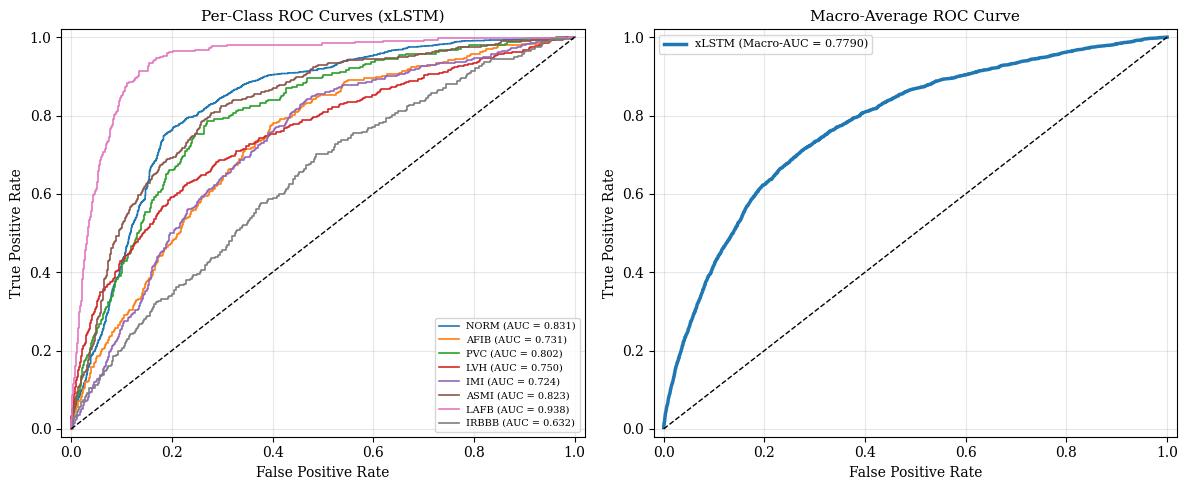

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Convert to numpy (safe)
y_true = np.array(y_true_xlstm)
y_pred = np.array(y_pred_xlstm)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LEFT: Per-class ROC
fpr_dict = {}
tpr_dict = {}

for i, label in enumerate(target_labels):
    if len(np.unique(y_true[:, i])) < 2:
        print(f"Skipping {label} (only one class present)")
        continue

    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    fpr_dict[i] = fpr
    tpr_dict[i] = tpr

    axes[0].plot(fpr, tpr, lw=1.2, label=f'{label} (AUC = {roc_auc:.3f})')

# Baseline
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)

axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])
axes[0].set_title('Per-Class ROC Curves (xLSTM)', fontsize=11)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

# RIGHT: Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in fpr_dict]))

mean_tpr = np.zeros_like(all_fpr)

for i in fpr_dict:
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])

mean_tpr /= len(fpr_dict)

macro_auc = auc(all_fpr, mean_tpr)

axes[1].plot(all_fpr, mean_tpr,
             lw=2.5,
             label=f'xLSTM (Macro-AUC = {macro_auc:.4f})')

# Baseline
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)

axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.02])
axes[1].set_title('Macro-Average ROC Curve', fontsize=11)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# SAVE + SHOW
plt.tight_layout()
plt.savefig('xlstm_roc_model.png', dpi=300, bbox_inches='tight')
plt.show()

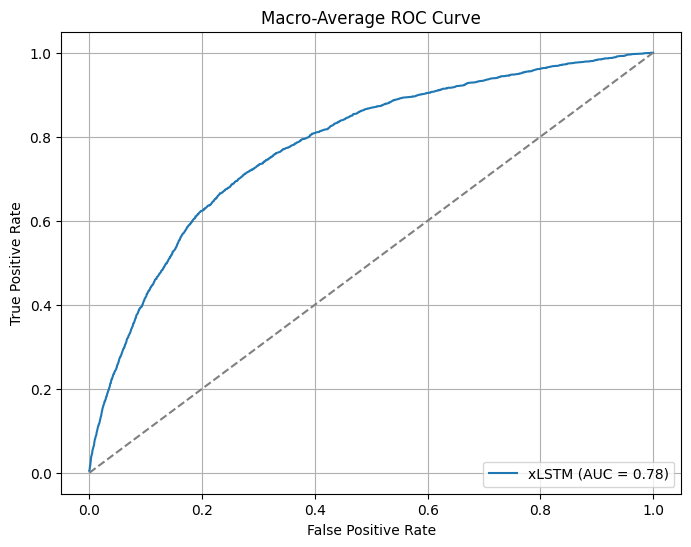

In [9]:
# Plot macro-average ROC
fpr, tpr, macro_auc = compute_macro_roc(y_true, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'xLSTM (AUC = {macro_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Macro-Average ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

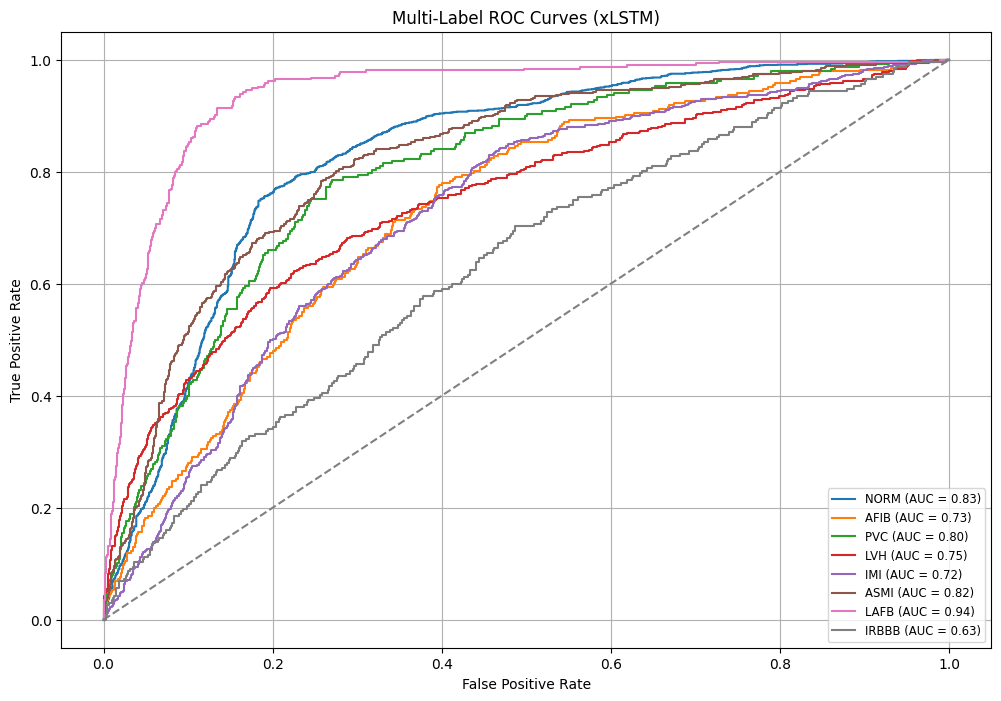

In [10]:
# ROC Curves
plt.figure(figsize=(12, 8))
for i, label in enumerate(mlb.classes_):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Label ROC Curves (xLSTM)')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)
plt.show()

In [11]:
import numpy as np

# After evaluation
np.save("y_true_xlstm.npy", y_true)
np.save("y_pred_xlstm.npy", y_pred)
